# Study 254 -- WSB-Mentions
## For the quants: rank-IC, HAC tests, bootstrap CI, sub-periods, synthetic controls

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wsb_mentions import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

mentions = data.mention_counts()
sig = st.mention_signal(mentions)

if HAVE_REAL:
    prices = data.fetch_meme_monthly(fetch=False, cache_path=CACHE_PATH)
    res = st.half_returns(sig, prices, q=0.50, min_stocks=6)
    spread = res["spread"].dropna()
    hype_x = (res["hype"] - res["basket"]).dropna()
    print(f"Real meme panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res)}  (avg {res['n_total'].mean():.0f} names, {res['n_hype'].mean():.0f} in the loud leg)")
else:
    prices = res = spread = hype_x = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real meme panel loaded: 38 months x 14 tickers
Portfolio months: 36  (avg 13 names, 7 in the loud leg)


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 36, 'n_names': 13, 'n_hype': 7, 'hype_ann': -25.9, 'hype_t': -0.85, 'quiet_ann': -22.4, 'quiet_t': -1.12, 'basket_ann': -23.2, 'spread_ann': -3.5, 'spread_bps': -29.3, 'spread_t': -0.14, 'spread_hit': 0.472, 'spread_sr_lo': -1.105, 'spread_sr_hi': 1.193, 'spread_frac_neg': 0.554, 'hype_xret_ann': -2.7, 'hype_xret_t': -0.2, 'sub_2021_mean': -49.1, 'sub_2021_t': -1.01, 'sub_2021_n': 12, 'sub_2022_mean': 0.8, 'sub_2022_t': 0.04, 'sub_2022_n': 12, 'sub_2023_mean': 37.9, 'sub_2023_t': 0.76, 'sub_2023_n': 12, 'reversal_ann': 3.5, 'reversal_t': 0.14, 'rank_ic': -0.035, 'rank_ic_p': 0.448, 'rank_ic_pairs': 468, 'turnover': 6.8, 'drag_bps': 4.1, 'net_spread_ann': -4.0, 'net_spread_t': -0.15, 'random_excess_bps': -17.4, 'syn_null_t': -0.52, 'syn_pos_t': 14.81, 'syn_rev_t': -16.01}


## Synthetic controls: the engine reads a planted link correctly

> 💡 *In plain words: before trusting the verdict on the real tape, we confirm the
> machinery isn't broken. We plant a known mention->return link in a synthetic
> basket and check the engine recovers it -- positive, negative, and null.*


In [3]:
# Positive control: high-buzz LEADS (premium=+0.15) -> loud-minus-quiet t >> 2
p_pos, m_pos, _ = data.synthetic_panel(premium=0.15, n_months=120, seed=254)
r_pos = st.half_returns(st.mention_signal(m_pos), p_pos, q=0.50)
s_pos = st.summarize(r_pos["spread"].dropna())
print(f"Positive control (premium=+0.15, buzz leads): spread t = {s_pos['tstat']:+.2f}")

# Reversal control: high-buzz LAGS (premium=-0.15) -> loud-minus-quiet t << -2
p_rev, m_rev, _ = data.synthetic_panel(premium=-0.15, n_months=120, seed=254)
r_rev = st.half_returns(st.mention_signal(m_rev), p_rev, q=0.50)
s_rev = st.summarize(r_rev["spread"].dropna())
print(f"Reversal control (premium=-0.15, buzz fades): spread t = {s_rev['tstat']:+.2f}")

# Null control: mentions carry no forward info (premium=0)
p_nul, m_nul, _ = data.synthetic_panel(premium=0.0, n_months=120, seed=254)
r_nul = st.half_returns(st.mention_signal(m_nul), p_nul, q=0.50)
s_nul = st.summarize(r_nul["spread"].dropna())
print(f"Null control     (premium= 0.00, no link)    : spread t = {s_nul['tstat']:+.2f}")
print("\n-> Engine recovers sign and significance when present; reads ~zero on the null.")


Positive control (premium=+0.15, buzz leads): spread t = +14.81


Reversal control (premium=-0.15, buzz fades): spread t = -16.01


Null control     (premium= 0.00, no link)    : spread t = -0.52

-> Engine recovers sign and significance when present; reads ~zero on the null.


## Primary spec on the real tape: loud-minus-quiet, 1-month hold

In [4]:
if HAVE_REAL:
    s_spread = st.summarize(spread)
    s_hype   = st.summarize(res["hype"].dropna())
    s_quiet  = st.summarize(res["quiet"].dropna())
    s_basket = st.summarize(res["basket"].dropna())
    s_hype_x = st.summarize(hype_x)
    print("=== Primary spec: buy loud half, short quiet half, hold 1 month ===")
    print(f"Portfolio months: {len(res)}  |  avg names: {res['n_total'].mean():.0f}  |  loud leg: {res['n_hype'].mean():.1f}")
    print()
    print(f"LOUD  : {s_hype['mean']*12*100:+.1f}%/yr   HAC t={s_hype['tstat']:+.2f}")
    print(f"QUIET : {s_quiet['mean']*12*100:+.1f}%/yr   HAC t={s_quiet['tstat']:+.2f}")
    print(f"BASKET: {s_basket['mean']*12*100:+.1f}%/yr  (the meme basket bled regardless of buzz)")
    print(f"SPREAD: {s_spread['mean']*12*100:+.1f}%/yr = {s_spread['mean']*10000:+.1f} bps/mo  HAC t={s_spread['tstat']:+.2f}  hit={s_spread['hit_rate']:.3f}")
    print(f"LOUD excess-basket: {s_hype_x['mean']*12*100:+.1f}%/yr  HAC t={s_hype_x['tstat']:+.2f}")
    try:
        from quantlab.stats import sharpe_ci_bootstrap
        ci = sharpe_ci_bootstrap(spread, n_boot=2000, periods_per_year=12, seed=254)
        print(f"\nBootstrap spread-Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]  ({ci['frac_negative']*100:.0f}% of resamples negative)")
        print("  -> CI straddles zero: no edge.")
    except ImportError:
        print(f"\n[quantlab.stats unavailable -- frozen CI: [{R['spread_sr_lo']:+.3f}, {R['spread_sr_hi']:+.3f}]]")
else:
    print(f"Frozen: spread = {R['spread_ann']:+.1f}%/yr  HAC t = {R['spread_t']:+.2f}  hit = {R['spread_hit']:.3f}")
    print(f"Bootstrap 95% CI: [{R['spread_sr_lo']:+.3f}, {R['spread_sr_hi']:+.3f}]  ({R['spread_frac_neg']*100:.0f}% negative)")


=== Primary spec: buy loud half, short quiet half, hold 1 month ===
Portfolio months: 36  |  avg names: 13  |  loud leg: 7.1

LOUD  : -25.9%/yr   HAC t=-0.85
QUIET : -22.4%/yr   HAC t=-1.12
BASKET: -23.2%/yr  (the meme basket bled regardless of buzz)
SPREAD: -3.5%/yr = -29.3 bps/mo  HAC t=-0.14  hit=0.472
LOUD excess-basket: -2.7%/yr  HAC t=-0.20



Bootstrap spread-Sharpe 95% CI: [-1.105, +1.193]  (55% of resamples negative)
  -> CI straddles zero: no edge.


## The cleanest test: pooled rank-IC

> 💡 *In plain words: forget portfolios for a second. Across every (stock, month)
> pair, does a higher mention rank line up with a higher next-month return rank?
> That is the Spearman rank information coefficient (rank-IC). If buzz forecasts
> returns, it should be reliably positive.*


In [5]:
import scipy.stats as ss
fwd = prices.pct_change().shift(-1) if HAVE_REAL else None
if HAVE_REAL:
    X, Y = [], []
    for t in sig.index:
        if t not in fwd.index: continue
        s = sig.loc[t].dropna(); f = fwd.loc[t].dropna()
        c = s.index.intersection(f.index)
        if len(c) < 6: continue
        X.append(s.loc[c].rank()); Y.append(f.loc[c].rank())
    X = pd.concat(X); Y = pd.concat(Y)
    rho, pval = ss.spearmanr(X, Y)
    print(f"Pooled rank-IC (Spearman): {rho:+.3f}  p = {pval:.3f}  over {len(X)} (stock, month) pairs")
else:
    rho, pval = R['rank_ic'], R['rank_ic_p']
    print(f"Frozen pooled rank-IC: {rho:+.3f}  p = {pval:.3f}  over {R['rank_ic_pairs']} pairs")
print("-> Indistinguishable from zero. Mention rank does not order next-month returns.")


Pooled rank-IC (Spearman): -0.035  p = 0.448  over 468 (stock, month) pairs
-> Indistinguishable from zero. Mention rank does not order next-month returns.


## Sub-periods: no edge in any single year either

  2021: mean=-49.1%/yr  HAC t=-1.01  n=12
  2022: mean=+0.8%/yr  HAC t=+0.04  n=12
  2023: mean=+37.9%/yr  HAC t=+0.76  n=12


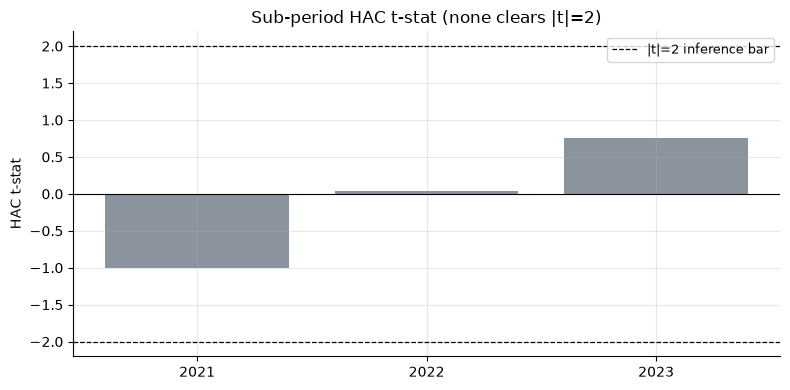

In [6]:
if HAVE_REAL:
    sub_stats = []
    for label in ["2021", "2022", "2023"]:
        sub = spread[label:label]
        s = st.summarize(sub)
        sub_stats.append({"period": label, "mean_ann": s["mean"]*12*100, "tstat": s["tstat"], "n": s["n"]})
        print(f"  {label}: mean={s['mean']*12*100:+.1f}%/yr  HAC t={s['tstat']:+.2f}  n={s['n']}")
    sts = pd.DataFrame(sub_stats)
else:
    sts = pd.DataFrame([
        {"period": "2021", "mean_ann": R["sub_2021_mean"], "tstat": R["sub_2021_t"], "n": R["sub_2021_n"]},
        {"period": "2022", "mean_ann": R["sub_2022_mean"], "tstat": R["sub_2022_t"], "n": R["sub_2022_n"]},
        {"period": "2023", "mean_ann": R["sub_2023_mean"], "tstat": R["sub_2023_t"], "n": R["sub_2023_n"]},
    ])
    for _, r in sts.iterrows():
        print(f"  {r['period']}: mean={r['mean_ann']:+.1f}%/yr  HAC t={r['tstat']:+.2f}  n={int(r['n'])}")

fig, ax = plt.subplots(figsize=(8, 4))
colors_sub = [GREEN if abs(t) >= 2 else GREY for t in sts["tstat"]]
ax.bar(sts["period"], sts["tstat"], color=colors_sub)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="|t|=2 inference bar")
ax.axhline(-2.0, color="black", ls="--", lw=0.9)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Sub-period HAC t-stat (none clears |t|=2)")
ax.set_ylabel("HAC t-stat")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Turnover, costs, and the random-portfolio null

In [7]:
if HAVE_REAL:
    drag = st.turnover_cost_drag(sig, prices, q=0.50, one_way_bps=30.0)
    avg_turnover = drag.mean() / 0.006
    net_spread = spread - drag.reindex(spread.index).fillna(drag.mean())
    s_net = st.summarize(net_spread)
    print(f"Avg monthly loud-leg turnover: {avg_turnover:.1%}")
    print(f"Avg drag @30bps one-way (illiquid + borrow): {drag.mean()*10000:.1f} bps/mo")
    print(f"Net spread @30bps: {s_net['mean']*12*100:+.1f}%/yr  HAC t={s_net['tstat']:+.2f}")
    print()
    rand = st.random_portfolio_returns(sig, prices, q=0.50, n_draws=200, seed=254)
    print(f"Random-half excess vs basket: mean={rand.mean()*10000:+.1f} bps  (null centred near zero)")
    print(f"  -> The mention-sorted loud leg is no better than a random half of the basket.")
else:
    print(f"Frozen: turnover={R['turnover']:.1f}%  drag={R['drag_bps']:.1f}bps/mo")
    print(f"Net spread @30bps: {R['net_spread_ann']:+.1f}%/yr  HAC t={R['net_spread_t']:+.2f}")
    print(f"Random-half excess: {R['random_excess_bps']:+.1f} bps")


Avg monthly loud-leg turnover: 6.8%
Avg drag @30bps one-way (illiquid + borrow): 4.1 bps/mo
Net spread @30bps: -4.0%/yr  HAC t=-0.15



Random-half excess vs basket: mean=-17.4 bps  (null centred near zero)
  -> The mention-sorted loud leg is no better than a random half of the basket.


## Verdict

In [8]:
print("=== Study 254 -- WSB-Mentions ===")
print()
print(f"Signal: NONE")
print(f"  Loud-minus-quiet spread HAC t = {R['spread_t']:+.2f} (a statistical zero)")
print(f"  Pooled rank-IC = {R['rank_ic']:+.3f} (p={R['rank_ic_p']:.2f}); hit rate {R['spread_hit']:.0%}")
print(f"  Bootstrap CI straddles zero; no sub-period clears |t|=2")
print(f"  Synthetic controls confirm the engine WOULD see a real link (t={R['syn_pos_t']:+.1f}/{R['syn_rev_t']:+.1f})")
print()
print(f"Tradability: MIRAGE")
print(f"  Net spread @30bps one-way = {R['net_spread_ann']:+.1f}%/yr (t={R['net_spread_t']:+.2f})")
print(f"  Illiquid meme names, heavy short borrow; loud leg ~ a random half")
print()
print("Endogeneity (named on Signal): mentions are CONTEMPORANEOUS -- Reddit gets")
print("  loud BECAUSE the price already moved, so the proxy can't lead the move.")
print("Survivorship (named on Signal): delisted blow-ups (WISH/BBBY) drop from the")
print("  short leg, so the headline is already an UPPER BOUND on any reversal edge.")
print()
print("Bottom line: None/Mirage -- WSB mention counts are folklore, not a forecast.")


=== Study 254 -- WSB-Mentions ===

Signal: NONE
  Loud-minus-quiet spread HAC t = -0.14 (a statistical zero)
  Pooled rank-IC = -0.035 (p=0.45); hit rate 47%
  Bootstrap CI straddles zero; no sub-period clears |t|=2
  Synthetic controls confirm the engine WOULD see a real link (t=+14.8/-16.0)

Tradability: MIRAGE
  Net spread @30bps one-way = -4.0%/yr (t=-0.15)
  Illiquid meme names, heavy short borrow; loud leg ~ a random half

Endogeneity (named on Signal): mentions are CONTEMPORANEOUS -- Reddit gets
  loud BECAUSE the price already moved, so the proxy can't lead the move.
Survivorship (named on Signal): delisted blow-ups (WISH/BBBY) drop from the
  short leg, so the headline is already an UPPER BOUND on any reversal edge.

Bottom line: None/Mirage -- WSB mention counts are folklore, not a forecast.
